### E-Commerce US Dataset -- Data Cleaning & EDA

\Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.titlesize"]=13

\Loading the integrated dataset

In [3]:
integrated_path = r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw_integrated"

master = pd.read_csv(os.path.join(integrated_path,"master_orders.csv"))
items_enriched = pd.read_csv(os.path.join(integrated_path,"items_enriched.csv"))

Insights:
 
 -- there is no duplicated record
 
 -- categorical variables has standard values
 
 -- data types for numeric and categorical columns are in correct types 
 
 -- so these steps are skipped for this dataset

\Date Conversion

In [4]:
master_date_cols = ["order_purchase_timestamp","order_approved_at",
             "order_delivered_carrier_date","order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in master_date_cols:
    master[col]=pd.to_datetime(master[col],errors="coerce")

master[master_date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [5]:
items_enriched["shipping_limit_date"] = pd.to_datetime(items_enriched["shipping_limit_date"],errors="coerce")

\Missing value treatment

In [6]:
master["is_delivered"]=master["order_delivered_customer_date"].notna().astype(int)
master["has_review"]=master["avg_review_score"].notna().astype(int)
master["n_reviews"]=master["n_reviews"].fillna(0).astype(int)

In [7]:
master["is_delivered"].value_counts()

is_delivered
1    9332
0     668
Name: count, dtype: int64

\Dropping Redundant columns

In [8]:
if "price_prod" in items_enriched.columns:
    items = items_enriched.drop(columns=["price_prod"])

\Outlier Detection

In [10]:
# Outlier Detection Fn
def detect_outlier(df,col):
    q1,q3=df[col].quantile(0.25),df[col].quantile(0.75)
    iqr=q3-q1
    lower,upper = q1-1.5*iqr, q3+1.5*iqr
    n=((df[col]<lower)|(df[col]>upper)).sum()
    return round(lower,1),round(upper,1),n,upper

In [11]:
#master 
for col in ["total_payment","total_price","n_items","customer_age"]:
    lower,upper,n,_=detect_outlier(master,col)
    print(f"   {col:16s}: fence[{lower},{upper}], {n} outliers ({n/len(master)*100:.1f}%)")

   total_payment   : fence[-1675.9,3857.7], 225 outliers (2.2%)
   total_price     : fence[-1761.1,3481.0], 221 outliers (2.2%)
   n_items         : fence[-2.0,6.0], 0 outliers (0.0%)
   customer_age    : fence[3.0,67.0], 35 outliers (0.4%)


In [12]:
#items_enriched
for col in ["price","freight_value","product_weight_g"]:
    lower,upper,n,_=detect_outlier(items_enriched,col)
    print(f"   {col:16s}: fence[{lower},{upper}], {n} outliers ({n/len(items_enriched)*100:.1f}%)")

   price           : fence[-947.1,1746.4], 863 outliers (4.0%)
   freight_value   : fence[-78.8,302.3], 0 outliers (0.0%)
   product_weight_g: fence[-3945.0,8135.0], 2297 outliers (10.5%)


\Flagging High Values

In [13]:
_,_,_,pay_upper =detect_outlier(master,"total_payment")
master["is_high_value"]= (master["total_payment"]>pay_upper).astype(int)
master["is_high_value"].value_counts()

is_high_value
0    9775
1     225
Name: count, dtype: int64

\Saving the cleaned dataset

In [14]:
master.to_csv(os.path.join(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed", "master_clean.csv"), index=False)
items.to_csv(os.path.join(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed", "items_clean.csv"), index=False)

### EDA

\Loading the Cleaned dataset

In [15]:
processed_path=r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\processed"

master=pd.read_csv(os.path.join(processed_path,"master_clean.csv"))
items=pd.read_csv(os.path.join(processed_path,"items_clean.csv")   )               

\Dates conversion

In [16]:
for col in master_date_cols:
    master[col]=pd.to_datetime(master[col],errors="coerce")
items["shipping_limit_date"]=pd.to_datetime(items["shipping_limit_date"],errors="coerce")
    

\Customer Analysis

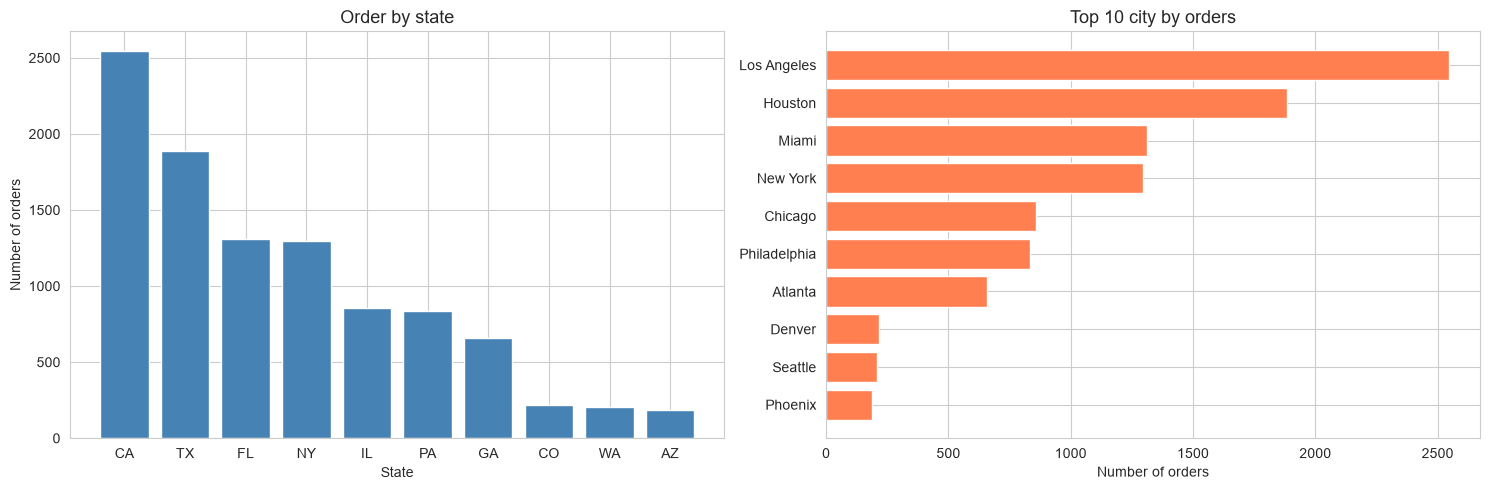

Top 3 states: customer_state
CA    2546
TX    1885
FL    1312
Name: count, dtype: int64


In [25]:
fig ,axes =plt.subplots(1,2,figsize =(15,5))

#order by state
state_count = master["customer_state"].value_counts()
axes[0].bar(state_count.index,state_count.values,color="steelblue")
axes[0].set_title("Order by state")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of orders")

#order by city
city_counts = master["customer_city"].value_counts().head(10)
axes[1].barh(city_counts.index[::-1],city_counts.values[::-1],color = "coral")
axes[1].set_title("Top 10 city by orders")
axes[1].set_xlabel("Number of orders")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_distribution.png",dpi = 100,bbox_inches = "tight")
plt.show()
print("Top 3 states:", state_count.head(3))

\Customer Demographics

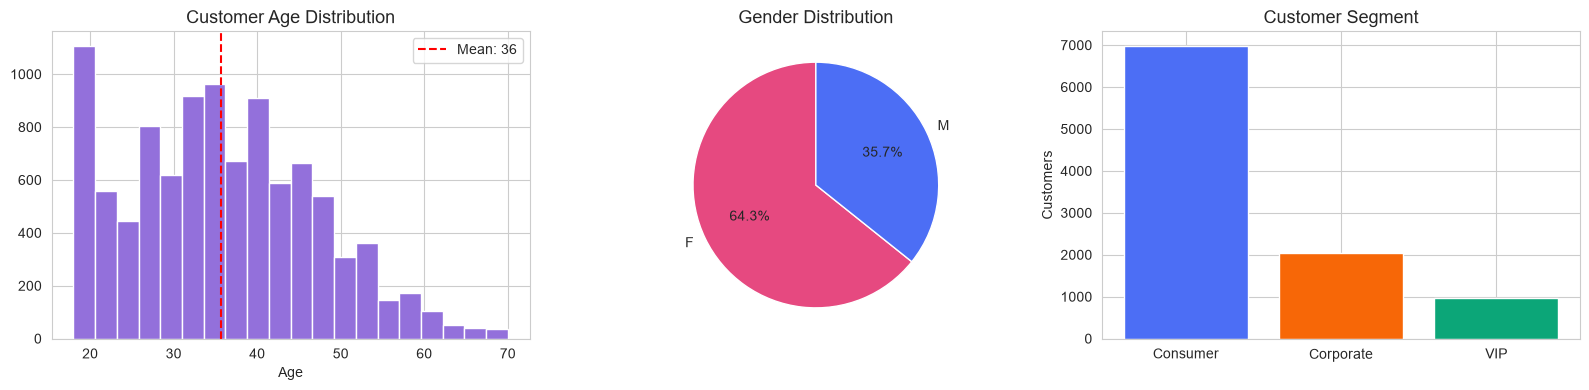

In [18]:
fig, axes = plt.subplots(1,3,figsize=(16,4))

#age distribution
axes[0].hist(master["customer_age"],bins=20,color="mediumpurple", edgecolor="white")
axes[0].axvline(master["customer_age"].mean(), color='red',linestyle ="--",
                label = f"Mean: {master["customer_age"].mean():.0f}")
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

#gender
gender_counts = master["customer_gender"].value_counts()
axes[1].pie(gender_counts.values,labels =gender_counts.index, autopct ="%1.1f%%",
            colors=["#E64980","#4C6EF5"],startangle=90)
axes[1].set_title("Gender Distribution")

#segment
seg_counts = master["customer_segment"].value_counts()
axes[2].bar(seg_counts.index,seg_counts.values,color=["#4C6EF5","#F76707","#0CA678"])
axes[2].set_title("Customer Segment")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_demograpies.png",dpi =100,bbox_inches ="tight")
plt.show()


\Customer Acquistion Trend

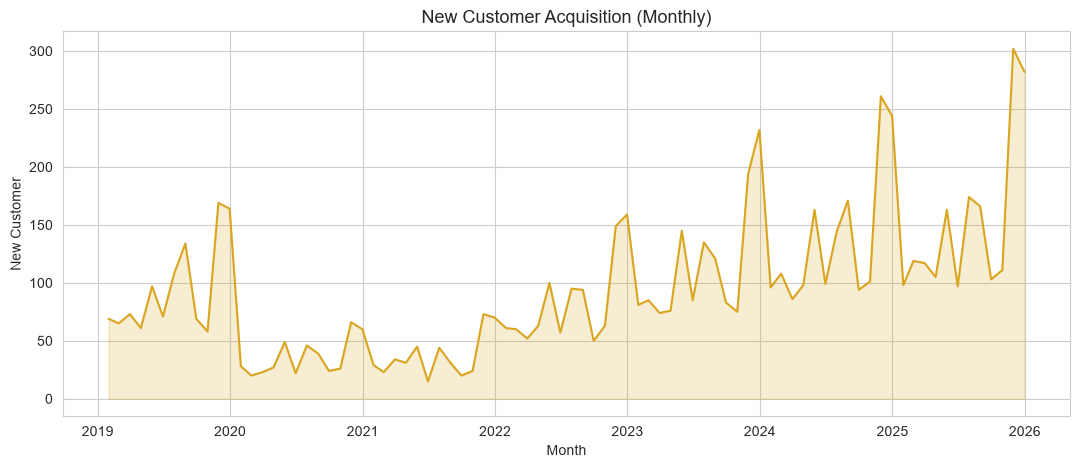

Total Unique Customer: 7898


In [89]:
master_sorted = master.sort_values("order_purchase_timestamp")
first_sorted = master_sorted.drop_duplicates("customer_unique_id",keep ="first")

monthly_new = first_sorted.set_index("order_purchase_timestamp").resample("ME").size()

plt.figure(figsize=(13,5))
plt.plot(monthly_new.index,monthly_new.values,color="goldenrod",linewidth=1.5)
plt.fill_between(monthly_new.index,monthly_new.values,alpha =0.2,color="goldenrod")
plt.title("New Customer Acquisition (Monthly)")
plt.xlabel("Month")
plt.ylabel("New Customer")
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\customer_acquisition_trend.png",dpi=100,bbox_inches="tight")
plt.show()            
print(f"Total Unique Customer: {first_sorted["customer_unique_id"].nunique()}")

\Order Analysis

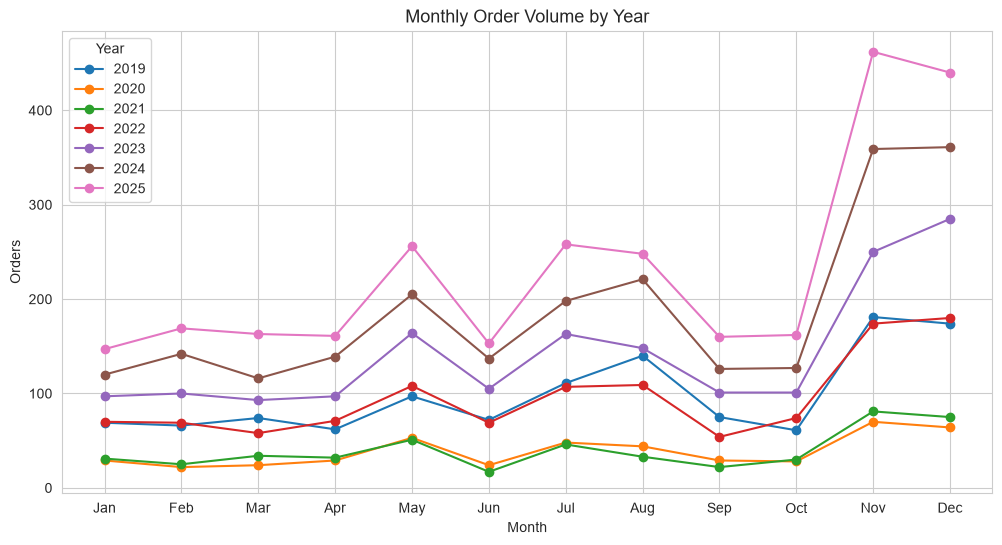

In [73]:
master["year"] = master["order_purchase_timestamp"].dt.year
master["month_num"] = master["order_purchase_timestamp"].dt.month

monthly_yearly_orders = (
    master.groupby(["year", "month_num"])
          .size()
          .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))

for year in monthly_yearly_orders.index:
    plt.plot(
        monthly_yearly_orders.columns,
        monthly_yearly_orders.loc[year],
        marker="o",
        label=year
    )

plt.xticks(
    range(1,13),
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.title("Monthly Order Volume by Year")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend(title="Year")
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\Monthly_Order_Volume_by_Year.png",dpi=100,bbox_inches="tight")
plt.show()

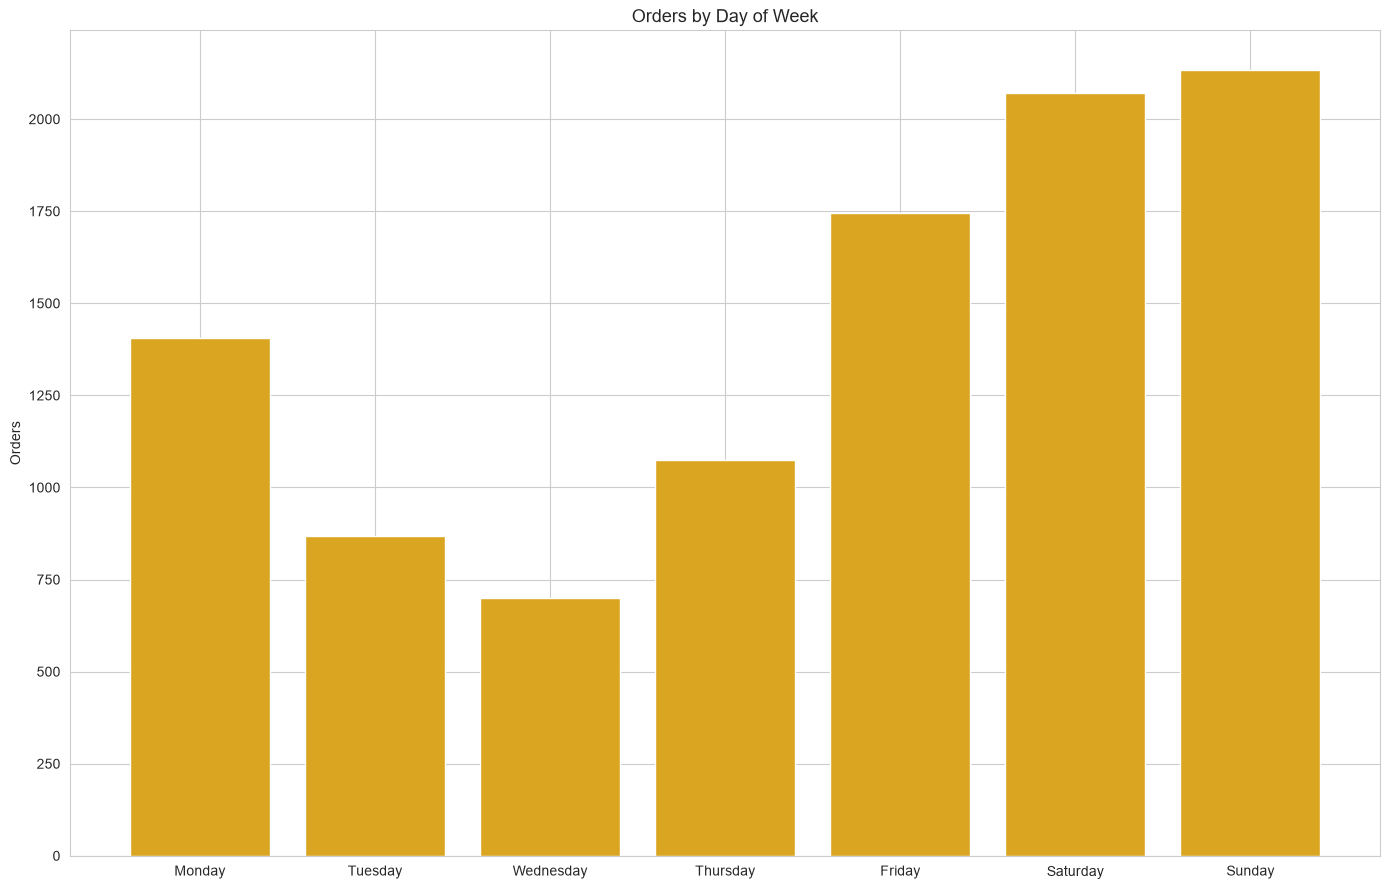

In [90]:
fig, axes = plt.subplots(1,1,figsize=(14,9))

#day of week pattern
master["day_of_week"] = master["order_purchase_timestamp"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = master["day_of_week"].value_counts().reindex(dow_order)
axes.bar(dow_counts.index,dow_counts.values,color="goldenrod")
axes.set_title("Orders by Day of Week")
axes.set_ylabel("Orders")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\order_volume_DOW.png",dpi=100,bbox_inches="tight")
plt.show()

\Order Status + Delivery Performance

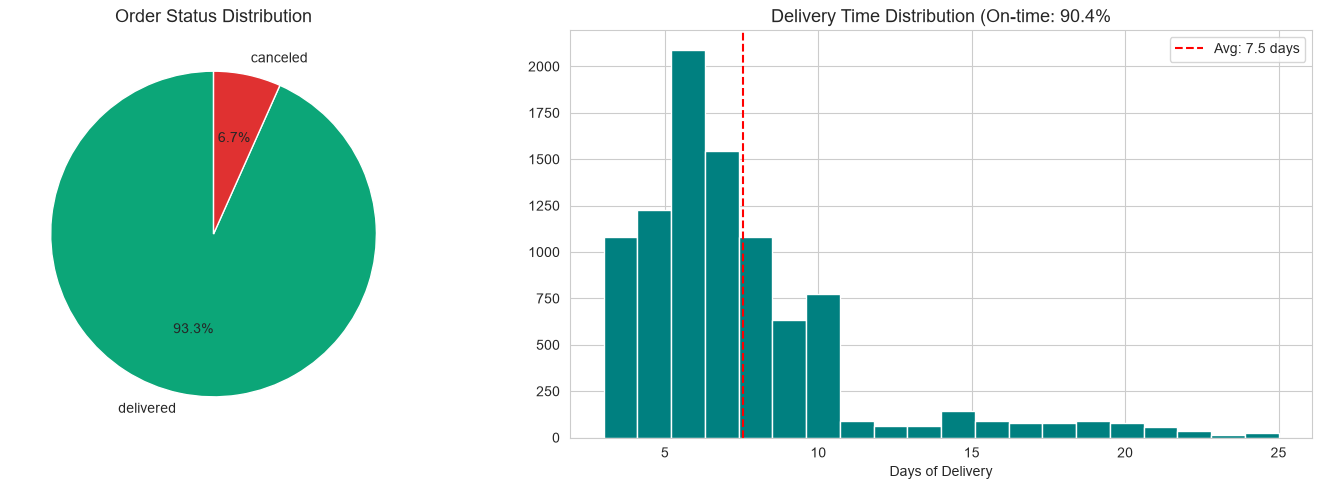

On-time delivery rate: 90.4%


In [50]:
fig, axes = plt.subplots(1,2,figsize=(15,5))

#order status
status_counts = master["order_status"].value_counts()
axes[0].pie(status_counts.values,labels=status_counts.index,autopct="%1.1f%%",
            colors=["#0CA678","#E03131"], startangle=90)
axes[0].set_title("Order Status Distribution")

#Delivery Performance
delivered = master[master["is_delivered"]==1].copy()
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] - 
                             delivered["order_purchase_timestamp"]).dt.days
delivered["est_days"] = (delivered["order_estimated_delivery_date"] - 
                             delivered["order_purchase_timestamp"]).dt.days
delivered["on_time"]=(delivered["delivery_days"]<=delivered["est_days"])

ontime_pct=delivered["on_time"].mean() *100
axes[1].hist(delivered["delivery_days"],bins=20,color="teal", edgecolor="white")
axes[1].axvline(delivered["delivery_days"].mean(),color="red",linestyle="--",
                label=f"Avg: {delivered["delivery_days"].mean():.1f} days")
axes[1].set_title(f"Delivery Time Distribution (On-time: {ontime_pct:.1f}%")
axes[1].set_xlabel("Days of Delivery")
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\order_delivery.png",dpi=100,bbox_inches="tight")
plt.show()
print(f"On-time delivery rate: {ontime_pct:.1f}%")

\Product Analysis

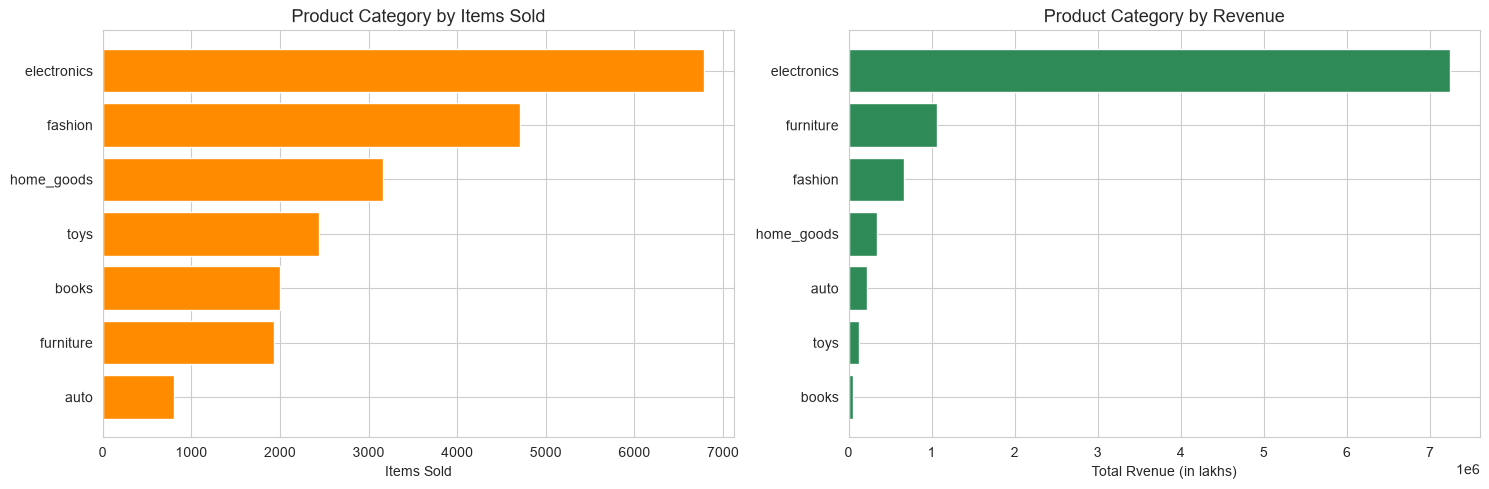

Top Category(volume): electronics
Top Category(revenue): electronics


In [56]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

#product category + popularity
cat_counts = items["product_category_name"].value_counts()
axes[0].barh(cat_counts.index[::-1],cat_counts.values[::-1],color="darkorange")
axes[0].set_title("Product Category by Items Sold")
axes[0].set_xlabel("Items Sold")

#category by revenue
cat_revenue = items.groupby("product_category_name")["price"].sum().sort_values()
axes[1].barh(cat_revenue.index,cat_revenue.values,color="seagreen")
axes[1].set_title("Product Category by Revenue")
axes[1].set_xlabel("Total Rvenue (in lakhs)")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\product_category.png",dpi=100,bbox_inches="tight")
plt.show()

print(f"Top Category(volume):", cat_counts.index[0])
print(f"Top Category(revenue):", cat_revenue.index[-1])

\Product Price Distribution

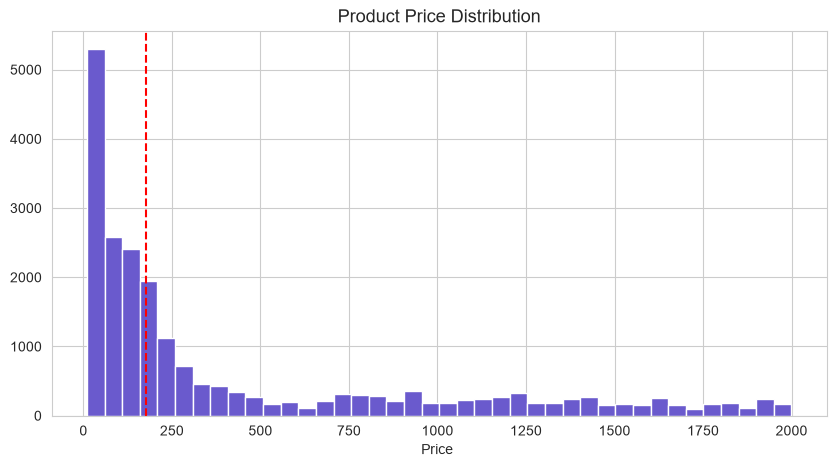

In [65]:
fig, ax = plt.subplots(figsize=(10,5))

items["price"].hist(bins=40,color="slateblue",edgecolor="white",ax=ax)
ax.axvline(items["price"].median(), color="red", linestyle="--",
                label=f"Median: ${items['price'].median():.0f}")
ax.set_title("Product Price Distribution")
ax.set_xlabel("Price ")
axes[0].legend()

plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\product_category.png",dpi=100,bbox_inches="tight")
plt.show()

\Seller Analysis

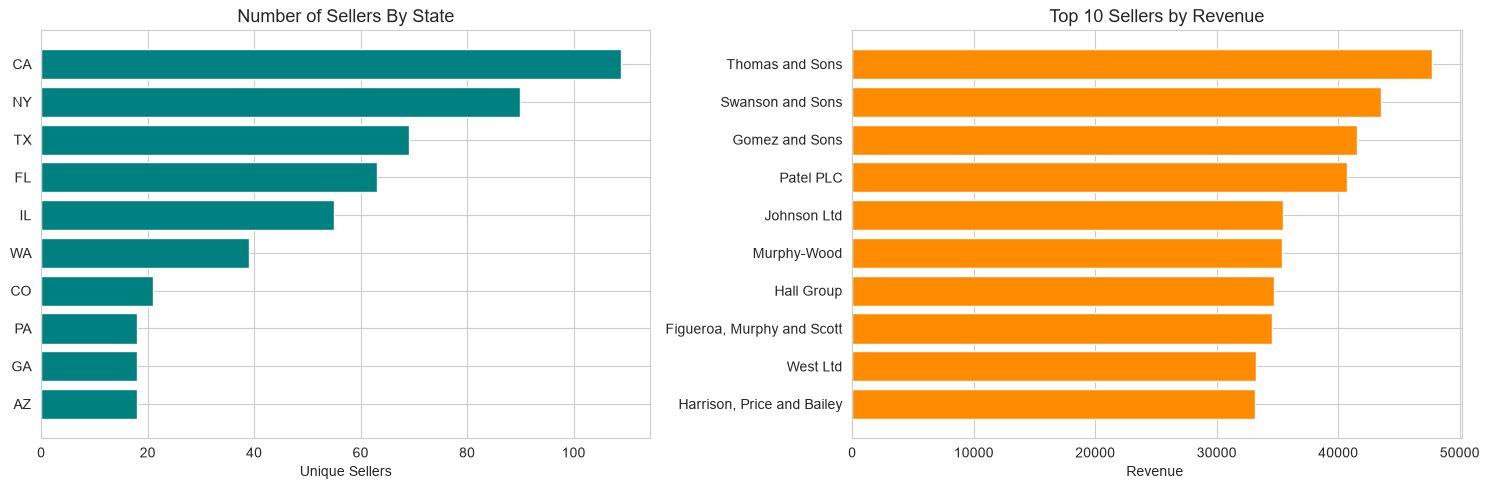

Most Sellers State: CA
Top Sellers: Thomas and Sons


In [78]:
fig, axes =plt.subplots(1,2,figsize=(15,5))

#seller distribution by region
seller_by_state = items.groupby("seller_state")["seller_id"].nunique().sort_values()
axes[0].barh(seller_by_state.index,seller_by_state.values,color="teal")
axes[0].set_title("Number of Sellers By State")
axes[0].set_xlabel("Unique Sellers")

#top Seller by revenue
top_sellers = items.groupby("seller_company_name")["price"].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_sellers.index[::-1],top_sellers.values[::-1],color="darkorange")
axes[1].set_title("Top 10 Sellers by Revenue")
axes[1].set_xlabel("Revenue ")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\seller_analysis.png",dpi=100,bbox_inches="tight")
plt.show()

print("Most Sellers State:" , seller_by_state.index[-1])
print("Top Sellers:" , top_sellers.index[0])

\Seller Contribution Analysis

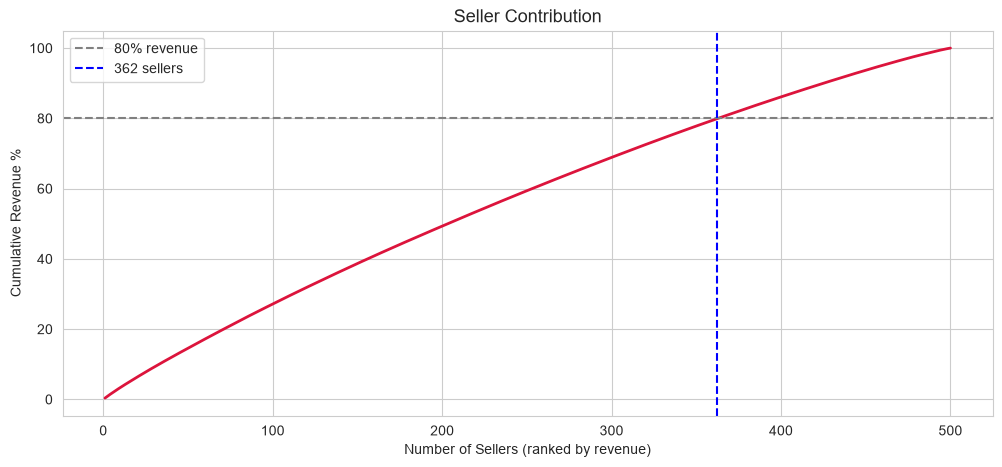

362 sellers (72%) generate 80% of revenue


In [84]:
seller_rev = items.groupby("seller_id")["price"].sum().sort_values(ascending=False)
cumulative_pct = (seller_rev.cumsum() / seller_rev.sum() * 100)

plt.figure(figsize=(12,5))
plt.plot(range(1,len(cumulative_pct)+1), cumulative_pct.values,color="crimson", linewidth=2)
plt.axhline(80, color="gray", linestyle="--",  label="80% revenue")

#80% revenue
sellers_80 = (cumulative_pct <=80).sum()
plt.axvline(sellers_80,color="blue",linestyle="--",label=f"{sellers_80} sellers")
plt.title("Seller Contribution")
plt.xlabel("Number of Sellers (ranked by revenue)")
plt.ylabel("Cumulative Revenue %")
plt.legend()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\seller_contribution.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{sellers_80} sellers ({sellers_80/len(seller_rev)*100:.0f}%) generate 80% of revenue")

\Payment Analysis

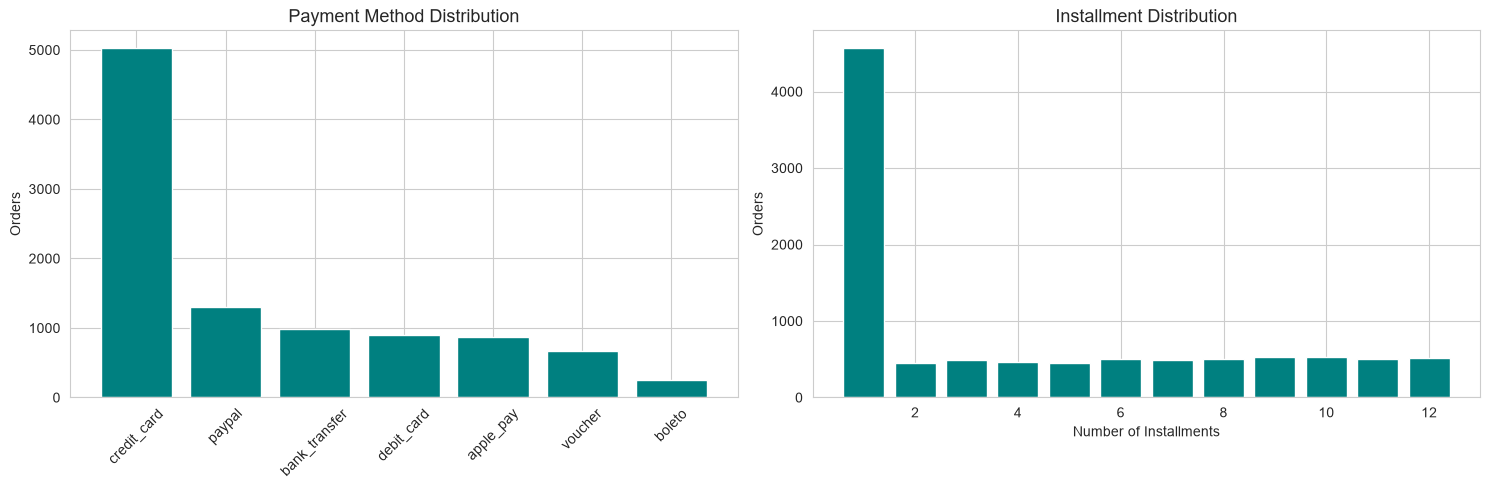

Top Payment: credit_card (50%)
Single Payment: 46%


In [91]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

#payment distribution
pay_counts = master["main_payment_type"].value_counts()
axes[0].bar(pay_counts.index,pay_counts.values,color="teal")
axes[0].set_title("Payment Method Distribution")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x",rotation=45)

#installment analysis
inst_counts = master["max_installments"].value_counts().sort_index()
axes[1].bar(inst_counts.index,inst_counts.values,color="teal")
axes[1].set_title("Installment Distribution")
axes[1].set_xlabel("Number of Installments")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\payment_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top Payment:",  pay_counts.index[0], f"({pay_counts.iloc[0]/len(master)*100:.0f}%)")
print("Single Payment:",f"{(master['max_installments']==1).mean()*100:.0f}%")  

\Revenue Trends

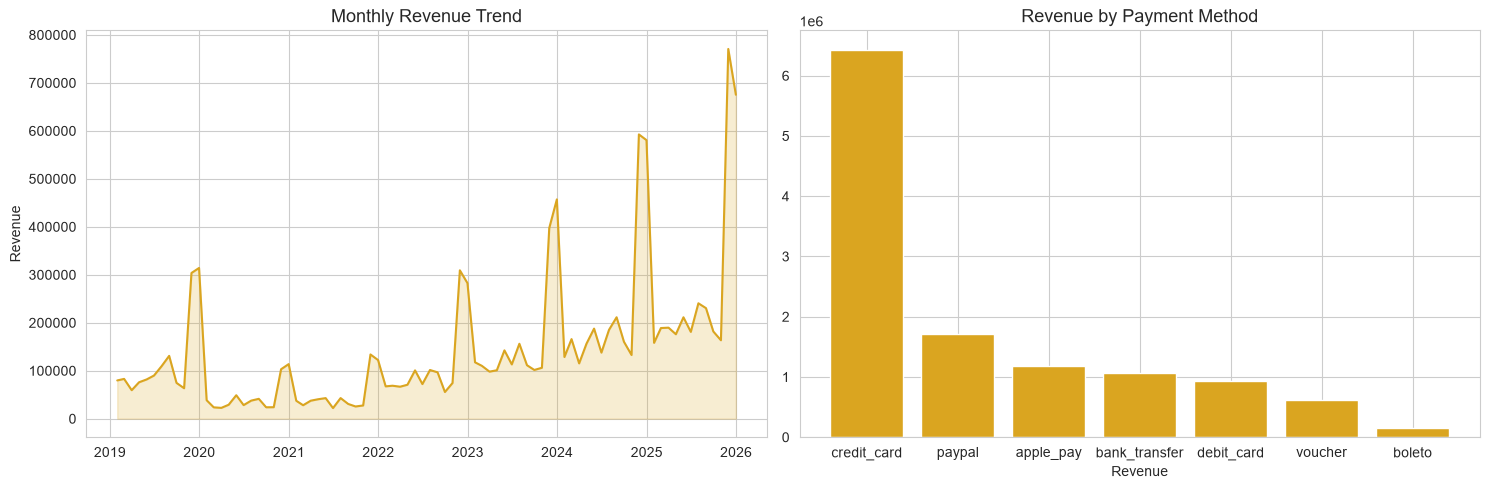

Total revenue: $12,089,314


In [98]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

#monthly revenue trend
monthly_rev = master.set_index("order_purchase_timestamp")["total_payment"].resample("ME").sum()
axes[0].plot(monthly_rev.index,monthly_rev.values,color="goldenrod",linewidth=1.5)
axes[0].fill_between(monthly_rev.index,monthly_rev.values,color="goldenrod",alpha=0.2)
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_ylabel("Revenue")

#revenue by payment type
rev_by_pay = master.groupby("main_payment_type")["total_payment"].sum().sort_values(ascending=False)
axes[1].bar(rev_by_pay.index,rev_by_pay.values,color="goldenrod")
axes[1].set_title("Revenue by Payment Method")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\revenue_trends.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Total revenue: ${master['total_payment'].sum():,.0f}")

\Review Analysis

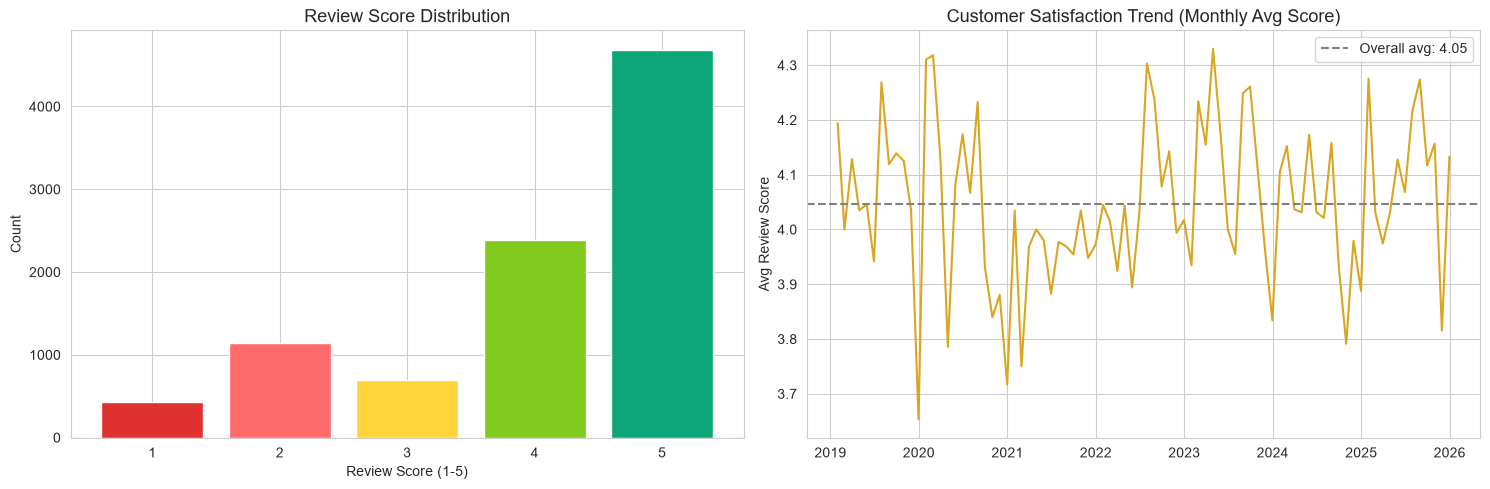

Avg review score: 4.05


In [100]:
fig, axes= plt.subplots(1,2,figsize=(15,5))

#review score distribution
reviewed = master[master["has_review"]==1]
score_counts = reviewed["avg_review_score"].round().value_counts().sort_index()
colors_score = ["#E03131","#FF6B6B","#FFD43B","#82C91E","#0CA678"]
axes[0].bar(score_counts.index, score_counts.values, color=colors_score)
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Review Score (1-5)"); axes[0].set_ylabel("Count")

#satisfaction trend 
reviewed_sorted = reviewed.set_index("order_purchase_timestamp")
monthly_satisfaction = reviewed_sorted["avg_review_score"].resample("ME").mean()
axes[1].plot(monthly_satisfaction.index,monthly_satisfaction.values,color="goldenrod",linewidth=1.5)
axes[1].axhline(reviewed["avg_review_score"].mean(), color="gray", linestyle="--",
                label=f"Overall avg: {reviewed['avg_review_score'].mean():.2f}")
axes[1].set_title("Customer Satisfaction Trend (Monthly Avg Score)")
axes[1].set_ylabel("Avg Review Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\review_analysis.png", dpi=100, bbox_inches="tight")
plt.show()
print("Avg review score:", round(reviewed["avg_review_score"].mean(), 2))

\Review Sentiment Observation

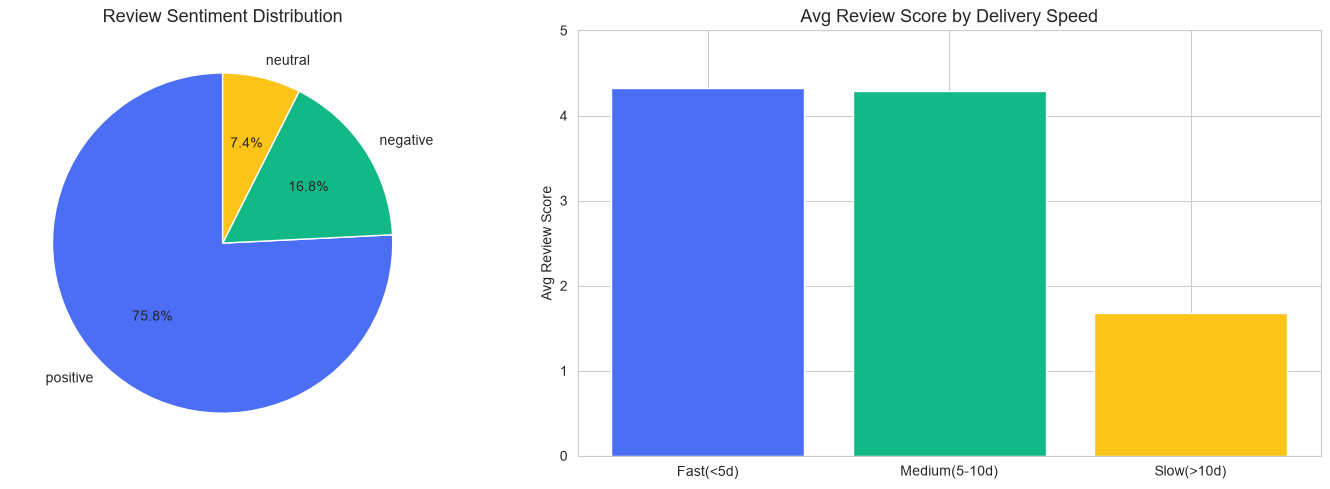

In [110]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

#sentiment category
reviewed = reviewed.copy()
reviewed["sentiment"] = pd.cut(reviewed["avg_review_score"], bins=[0,2.5,3.5,5],
                               labels=["negative","neutral","positive"])
sent_counts = reviewed["sentiment"].value_counts()
axes[0].pie(sent_counts.values,labels=sent_counts.index,autopct="%1.1f%%",
            colors=["#4C6EF5", "#12B886", "#FCC419"], startangle=90)
axes[0].set_title("Review Sentiment Distribution")

#delivery impact --based on review
delivered = master[master["is_delivered"]==1].copy()
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] -
                               delivered["order_purchase_timestamp"]).dt.days
delivered = delivered[delivered["has_review"]==1]
delivered["delivery_bucket"] = pd.cut(delivered["delivery_days"],bins=[0,5,10,100],
                                      labels=["Fast(<5d)","Medium(5-10d)","Slow(>10d)"])
avg_score_by_delivery = delivered.groupby("delivery_bucket")["avg_review_score"].mean()
axes[1].bar(avg_score_by_delivery.index, avg_score_by_delivery.values, color=["#4C6EF5", "#12B886", "#FCC419"])
axes[1].set_title("Avg Review Score by Delivery Speed")
axes[1].set_ylabel("Avg Review Score")
axes[1].set_ylim(0,5)

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\review_sentiment.png", dpi=100, bbox_inches="tight")
plt.show()

\Business Insights

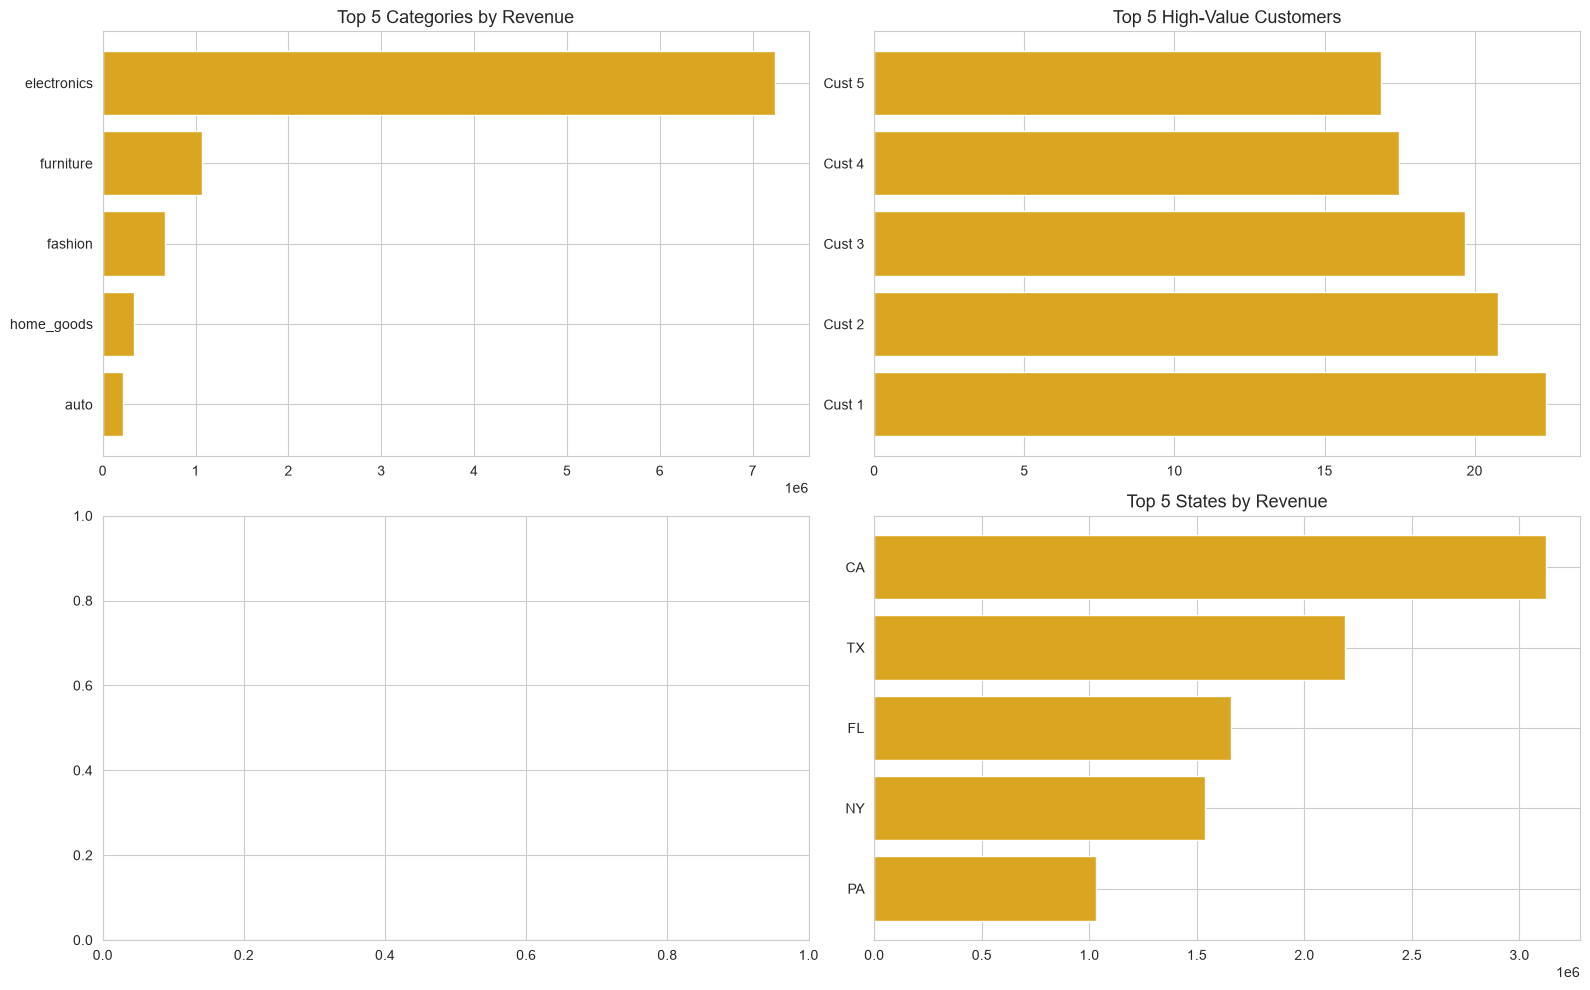

In [114]:
fig, axes = plt.subplots(2,2,figsize=(16,10))

#top categories by revenue
top_cat = items.groupby("product_category_name")["price"].sum().sort_values().tail()
axes[0,0].barh(top_cat.index,top_cat.values,color="goldenrod")
axes[0,0].set_title("Top 5 Categories by Revenue")

#High-value customer
top_customer = master.groupby("customer_unique_id")["total_payment"].sum().sort_values(ascending=False).tail()
axes[0,1].barh([f"Cust {i+1}" for i in range(len(top_customer))], top_customer.values ,color="goldenrod")
axes[0,1].set_title("Top 5 High-Value Customers")

#regional sales
top_region = master.groupby("customer_state")["total_payment"].sum().sort_values().tail(5)
axes[1,1].barh(top_region.index, top_region.values, color="goldenrod")
axes[1,1].set_title("Top 5 States by Revenue")

plt.tight_layout()
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\EDA visuals\business_insights.png", dpi=100, bbox_inches="tight")
plt.show()